In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib as mpl


DATA_PATH = '/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/ML/taxi_prediction/train.csv'

def load_csv(path):
    data_frame = pd.read_csv(path)
    return data_frame

df = load_csv(DATA_PATH)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                50000 non-null  object 
 1   fare_amount        50000 non-null  float64
 2   pickup_datetime    50000 non-null  object 
 3   pickup_longitude   50000 non-null  float64
 4   pickup_latitude    50000 non-null  float64
 5   dropoff_longitude  50000 non-null  float64
 6   dropoff_latitude   50000 non-null  float64
 7   passenger_count    50000 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 3.1+ MB


In [42]:
df = df.drop(columns=['key', 'passenger_count'])
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278
1,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004
2,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562
3,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092
4,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762


In [43]:
missing_values = df.isnull().sum()

missing_values

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
dtype: int64

⭐️ 결측치 없음!

### 📌 이상치 제거   


1. 요금이 음수인 데이터 제거    

2. 이동거리가 음수이거나 0인 데이터 제거

In [45]:
# 음수값을 가지는 데이터의 인덱스를 반환하는 함수
def get_negative_index(series):
    return series[series < 0].index.tolist()

# 1. 요금이 음수인 데이터 제거
idx_fare_amount = get_negative_index(df['fare_amount'])

# 2. 이동 거리가 음수이거나 0인 데이터 제거
idx_zero_or_negative_distance = df[
    (df['pickup_longitude'] == df['dropoff_longitude']) &
    (df['pickup_latitude'] == df['dropoff_latitude'])
].index.tolist()

# 제거할 인덱스 통합
total_index4remove = set(idx_fare_amount + idx_zero_or_negative_distance)

# 이상치 제거
df_cleaned = df.drop(index=total_index4remove).reset_index(drop=True)

# 데이터 확인
df_cleaned.info(), df_cleaned.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48545 entries, 0 to 48544
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fare_amount        48545 non-null  float64
 1   pickup_datetime    48545 non-null  object 
 2   pickup_longitude   48545 non-null  float64
 3   pickup_latitude    48545 non-null  float64
 4   dropoff_longitude  48545 non-null  float64
 5   dropoff_latitude   48545 non-null  float64
dtypes: float64(5), object(1)
memory usage: 2.2+ MB


(None,
    fare_amount          pickup_datetime  pickup_longitude  pickup_latitude  \
 0          4.5  2009-06-15 17:26:21 UTC        -73.844311        40.721319   
 1         16.9  2010-01-05 16:52:16 UTC        -74.016048        40.711303   
 2          5.7  2011-08-18 00:35:00 UTC        -73.982738        40.761270   
 3          7.7  2012-04-21 04:30:42 UTC        -73.987130        40.733143   
 4          5.3  2010-03-09 07:51:00 UTC        -73.968095        40.768008   
 
    dropoff_longitude  dropoff_latitude  
 0         -73.841610         40.712278  
 1         -73.979268         40.782004  
 2         -73.991242         40.750562  
 3         -73.991567         40.758092  
 4         -73.956655         40.783762  )

In [46]:
df_filtered.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_miles
count,48225.000000,48225.000000,48225.000000,48225.000000,48225.000000,48225.00000,48225.000000
mean,11.344917,-73.975665,40.750899,-73.974408,40.751414,1.67635,2.090037
std,9.414746,0.034376,0.027255,0.034530,0.031108,1.29065,2.225109
min,0.000000,-74.438233,40.121653,-74.308235,40.164927,1.00000,0.000052
25%,6.000000,-73.992328,40.736527,-73.991343,40.735917,1.00000,0.800363
50%,8.500000,-73.982147,40.753452,-73.980523,40.754135,1.00000,1.357870
75%,12.500000,-73.968539,40.767767,-73.965547,40.768482,2.00000,2.465626
max,165.000000,-73.644948,40.993260,-73.513693,40.978090,6.00000,24.529889


### 📌 하버사인 공식을 사용해 거리 계산하기

In [26]:
%pip install haversine

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [27]:
from haversine import haversine

# haversine 라이브러리를 사용하여 거리 계산
def haversine_distance_haversine(lat1, lon1, lat2, lon2):
    return haversine((lat1, lon1), (lat2, lon2), unit='mi')  # 마일 단위

In [9]:
# 새로운 거리 컬럼 적용
df_cleaned['distance_miles'] = df_cleaned.apply(
    lambda row: haversine_distance_haversine(
        row['pickup_latitude'], row['pickup_longitude'],
        row['dropoff_latitude'], row['dropoff_longitude']
    ), axis=1
)

ValueError: Latitude 401.083332 is out of range [-90, 90]

### 📌 위도/경도 이상치 제거   

바로 직전 셀의 에러는 401.083332와 같이 위도 값이 -90 ~ 90 범위를 벗어났다는 오류이다.   

이러한 결측치를 제거함과 동시에 뉴욕의 택시 데이터셋을 분석하는 것이므로 뉴욕의 위도/경도 범위 이외의 값을 제거하려 한다.   

뉴욕시의 정상적인 위도/경도 범위는   

- 위도: 40.0~41.0   
- 경도: -74.5~-73.5

In [28]:
# 위도(latitude)와 경도(longitude)가 정상 범위를 벗어난 데이터 제거
df_cleaned = df_cleaned[
    (df_cleaned['pickup_latitude'] >= 40.0) & (df_cleaned['pickup_latitude'] <= 41.0) &
    (df_cleaned['dropoff_latitude'] >= 40.0) & (df_cleaned['dropoff_latitude'] <= 41.0) &
    (df_cleaned['pickup_longitude'] >= -74.5) & (df_cleaned['pickup_longitude'] <= -73.5) &
    (df_cleaned['dropoff_longitude'] >= -74.5) & (df_cleaned['dropoff_longitude'] <= -73.5)
].reset_index(drop=True)

# 하버사인 거리 계산
df_cleaned['distance_miles'] = df_cleaned.apply(
    lambda row: haversine_distance_haversine(
        row['pickup_latitude'], row['pickup_longitude'],
        row['dropoff_latitude'], row['dropoff_longitude']
    ), axis=1
)

### 100마일 / 200 달러 제한두기

In [29]:
df_filtered = df_cleaned[(df_cleaned['distance_miles'] <= 100) & (df_cleaned['fare_amount'] <= 200)]

### 📌 상관계수

In [30]:
corr = df_filtered[['distance_miles', 'fare_amount']].corr()

print(corr)

                distance_miles  fare_amount
distance_miles        1.000000     0.878473
fare_amount           0.878473     1.000000


### 📌 모델 학습

In [31]:
X = df_filtered[['distance_miles']]
y = df_filtered['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42)

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### 📌 기울기, 절편, 예측값

In [33]:
print('기울기: ', {model.coef_[0]})
print('절편: ', {model.intercept_})

y_pred = model.predict(X_test)

기울기:  {np.float64(3.7030559475584606)}
절편:  {np.float64(3.605371794053891)}


### 📌 Statsmodels OLS 활용

In [41]:
# X에 상수항 추가 (OLS 모델은 상수를 직접 포함해야 함)
X_train_ols = sm.add_constant(X_train)

# OLS 회귀 모델 학습
ols_model = sm.OLS(y_train, X_train_ols).fit()

# 결과 출력
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                 1.264e+05
Date:                Wed, 19 Mar 2025   Prob (F-statistic):               0.00
Time:                        10:33:14   Log-Likelihood:            -1.1344e+05
No. Observations:               38580   AIC:                         2.269e+05
Df Residuals:                   38578   BIC:                         2.269e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.6054      0.032    112.

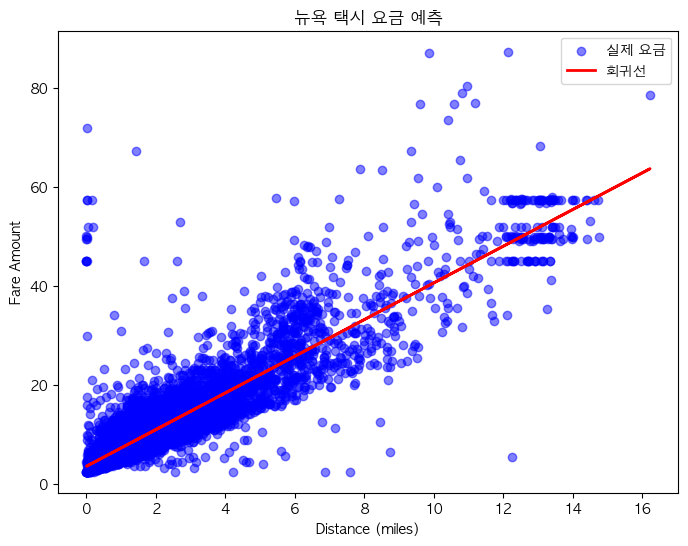

In [40]:
mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, alpha=0.5, label="실제 요금", color="blue")
plt.plot(X_test, y_pred, color='red', linewidth=2, label="회귀선")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare Amount")
plt.title("뉴욕 택시 요금 예측")
plt.legend()
plt.show()